In [67]:
#importing the libarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


from warnings import filterwarnings
filterwarnings("ignore")
# !pip install missingno 
# !pip install tree
# !pip install xgboost 

 ## Data Collection 😎


In [68]:
df=pd.read_csv(r"D:\balaji\proj excel\ipl.csv")  #Retrive the data from Excel
df.head()  

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


## Data Understanding 🥱

In [69]:
df.shape 

(76014, 15)

In [70]:
df.duplicated().sum() #checking whether duplicates is there or not.

0

In [71]:
df.info()  #it's used to check the column_names and their data_types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


Text(0.5, 1.0, 'visulizing the values using missingno')

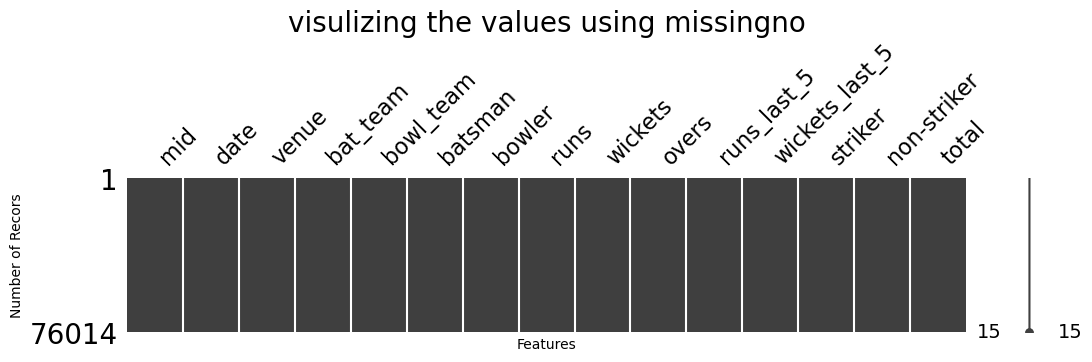

In [72]:
import missingno as mn   # I'm using this method to show the null values in data 
mn.matrix(df,figsize=(12,2))
plt.xlabel("Features",fontdict={"fontsize":10})
plt.ylabel("Number of Recors",fontdict={"fontsize":10})
plt.title("visulizing the values using missingno",fontdict={"fontsize":20})

In [73]:
df.describe()  # this method is used to show the all aggregrate function 

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


## Data Preprocessing 🫠

In [74]:
df.columns 

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [75]:
df['bat_team'].unique() #checking the unique name of batsmans teams

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Deccan Chargers', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Daredevils',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant'], dtype=object)

In [76]:
df['bowl_team'].unique() #checking the unique name of bowlers teams

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Kolkata Knight Riders', 'Rajasthan Royals',
       'Mumbai Indians', 'Chennai Super Kings', 'Deccan Chargers',
       'Pune Warriors', 'Kochi Tuskers Kerala', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant'], dtype=object)

In [77]:
temp=df.copy()  #copying the orginal data 

In [78]:
# converting old team name into new team names
teams = [
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [79]:
#replacing some old team names to new team names

temp['bat_team']=temp['bat_team'].str.replace('Deccan Chargers','Sunrisers Hyderabad')
temp['bowl_team']=temp['bowl_team'].str.replace('Deccan Chargers','Sunrisers Hyderabad')

temp['bat_team']=temp['bat_team'].str.replace('Delhi Daredevils','Delhi Capitals')
temp['bowl_team']=temp['bowl_team'].str.replace('Delhi Daredevils','Delhi Capitals')

In [80]:
temp['bat_team'].unique() #after replacing the team names

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Sunrisers Hyderabad', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Capitals',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants',
       'Gujarat Lions', 'Rising Pune Supergiant'], dtype=object)

In [81]:
temp['bowl_team'].unique() #after replacing the team names

array(['Royal Challengers Bangalore', 'Kings XI Punjab', 'Delhi Capitals',
       'Kolkata Knight Riders', 'Rajasthan Royals', 'Mumbai Indians',
       'Chennai Super Kings', 'Sunrisers Hyderabad', 'Pune Warriors',
       'Kochi Tuskers Kerala', 'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant'], dtype=object)

In [82]:
temp=temp[(temp['bat_team'].isin(teams)) & (temp['bowl_team'].isin(teams))]

In [83]:
temp['bat_team'].unique() #final change to team names

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Sunrisers Hyderabad', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Capitals'], dtype=object)

In [84]:
temp['bowl_team'].unique() #final change to team names

array(['Royal Challengers Bangalore', 'Kings XI Punjab', 'Delhi Capitals',
       'Kolkata Knight Riders', 'Rajasthan Royals', 'Mumbai Indians',
       'Chennai Super Kings', 'Sunrisers Hyderabad'], dtype=object)

In [85]:
df=temp

In [86]:
df.bat_team.unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Sunrisers Hyderabad', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Capitals'], dtype=object)

In [87]:
temp=df.copy()

In [88]:
df=df[(df.overs)>5.0] # taking all data above 5 overs

In [89]:
temp.shape,df.shape

((62464, 15), (46538, 15))

In [90]:
df.columns

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [91]:
df.head(2)

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
32,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,Z Khan,61,0,5.1,59,0,41,10,222
33,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,Z Khan,61,1,5.2,59,1,41,10,222


### How many unique values in each column

In [116]:
for col in df.columns:
    print(f"columns {col} has {df[col].nunique()} unique values")

columns runs has 226 unique values
columns wickets has 11 unique values
columns overs has 15 unique values
columns runs_last_5 has 84 unique values
columns wickets_last_5 has 8 unique values
columns total has 132 unique values
columns season has 10 unique values
columns bat_team_Chennai Super Kings has 2 unique values
columns bat_team_Delhi Capitals has 2 unique values
columns bat_team_Kings XI Punjab has 2 unique values
columns bat_team_Kolkata Knight Riders has 2 unique values
columns bat_team_Mumbai Indians has 2 unique values
columns bat_team_Rajasthan Royals has 2 unique values
columns bat_team_Royal Challengers Bangalore has 2 unique values
columns bat_team_Sunrisers Hyderabad has 2 unique values
columns bowl_team_Chennai Super Kings has 2 unique values
columns bowl_team_Delhi Capitals has 2 unique values
columns bowl_team_Kings XI Punjab has 2 unique values
columns bowl_team_Kolkata Knight Riders has 2 unique values
columns bowl_team_Mumbai Indians has 2 unique values
columns bo

### Droping not need columns in table.its used to retrive the predicting fast

In [93]:
column=["mid","venue","batsman","bowler","striker","non-striker"]
df.drop(column,inplace=True,axis=1)

In [94]:
df.head()

,date,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
32,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,59,0,222
33,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,59,1,222
34,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.3,59,1,222
35,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.4,59,1,222
36,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.5,58,1,222


In [95]:
df.date.dtype

dtype('O')

In [96]:
df.date.head()

32    2008-04-18
33    2008-04-18
34    2008-04-18
35    2008-04-18
36    2008-04-18
Name: date, dtype: object

In [97]:
df["season"]=df["date"].apply(lambda x:x.split("-")[0]).astype(int)

In [98]:
df["season"]

32       2008
33       2008
34       2008
35       2008
36       2008
         ... 
75884    2017
75885    2017
75886    2017
75887    2017
75888    2017
Name: season, Length: 46538, dtype: int32

Text(0.5, 1.0, 'each season data sets')

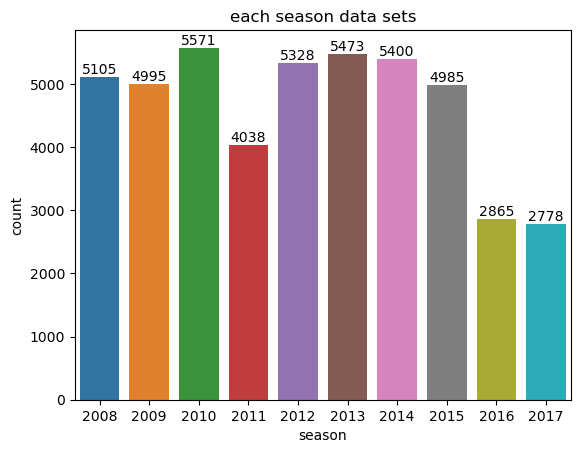

In [99]:
#visualizing the number of season and runs in overnall
import seaborn as sns 
ax=sns.countplot(data=df,x="season")
ax.bar_label(ax.containers[0])
plt.title("each season data sets")

In [100]:
df.drop(["date"],axis=1,inplace=True) #dropping the date

In [101]:
pd.DataFrame(df.groupby(by="bat_team")["total"].mean()) #groupig the team to view average score of team

,total
bat_team,
Chennai Super Kings,166.729183
Delhi Capitals,154.936988
Kings XI Punjab,162.889647
Kolkata Knight Riders,158.527903
Mumbai Indians,164.427494
Rajasthan Royals,158.829855
Royal Challengers Bangalore,163.131187
Sunrisers Hyderabad,161.570765


### Taking dummies to bat_team and bow_team 

In [102]:
df=pd.get_dummies(data=df,columns=["bat_team","bowl_team"])

In [105]:
df=df.astype(int) #convert every columns value into int

In [106]:
df

,runs,wickets,overs,runs_last_5,wickets_last_5,total,season,bat_team_Chennai Super Kings,bat_team_Delhi Capitals,bat_team_Kings XI Punjab,...,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Chennai Super Kings,bowl_team_Delhi Capitals,bowl_team_Kings XI Punjab,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Rajasthan Royals,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad
32,61,0,5,59,0,222,2008,0,0,0,...,0,0,0,0,0,0,0,0,1,0
33,61,1,5,59,1,222,2008,0,0,0,...,0,0,0,0,0,0,0,0,1,0
34,61,1,5,59,1,222,2008,0,0,0,...,0,0,0,0,0,0,0,0,1,0
35,61,1,5,59,1,222,2008,0,0,0,...,0,0,0,0,0,0,0,0,1,0
36,61,1,5,58,1,222,2008,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75884,106,9,18,29,4,107,2017,0,0,0,...,0,0,0,0,0,0,1,0,0,0
75885,107,9,18,29,4,107,2017,0,0,0,...,0,0,0,0,0,0,1,0,0,0
75886,107,9,18,28,4,107,2017,0,0,0,...,0,0,0,0,0,0,1,0,0,0
75887,107,9,18,24,4,107,2017,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [107]:
df=df.sample(df.shape[0]) # shuffling the data

# Data Splitting 😉

In [109]:
from sklearn.model_selection import train_test_split
x=df.drop(["total","season"],axis=1)
y=df["total"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [110]:
x_train.shape 

(32576, 21)

In [478]:
y_train.shape

(32576,)

In [479]:
x_test.shape

(13962, 21)

In [480]:
y_test.head()

7967     168
23245    168
33993    190
37117    136
51726    198
Name: total, dtype: int32

## co-relation of table 

<Axes: >

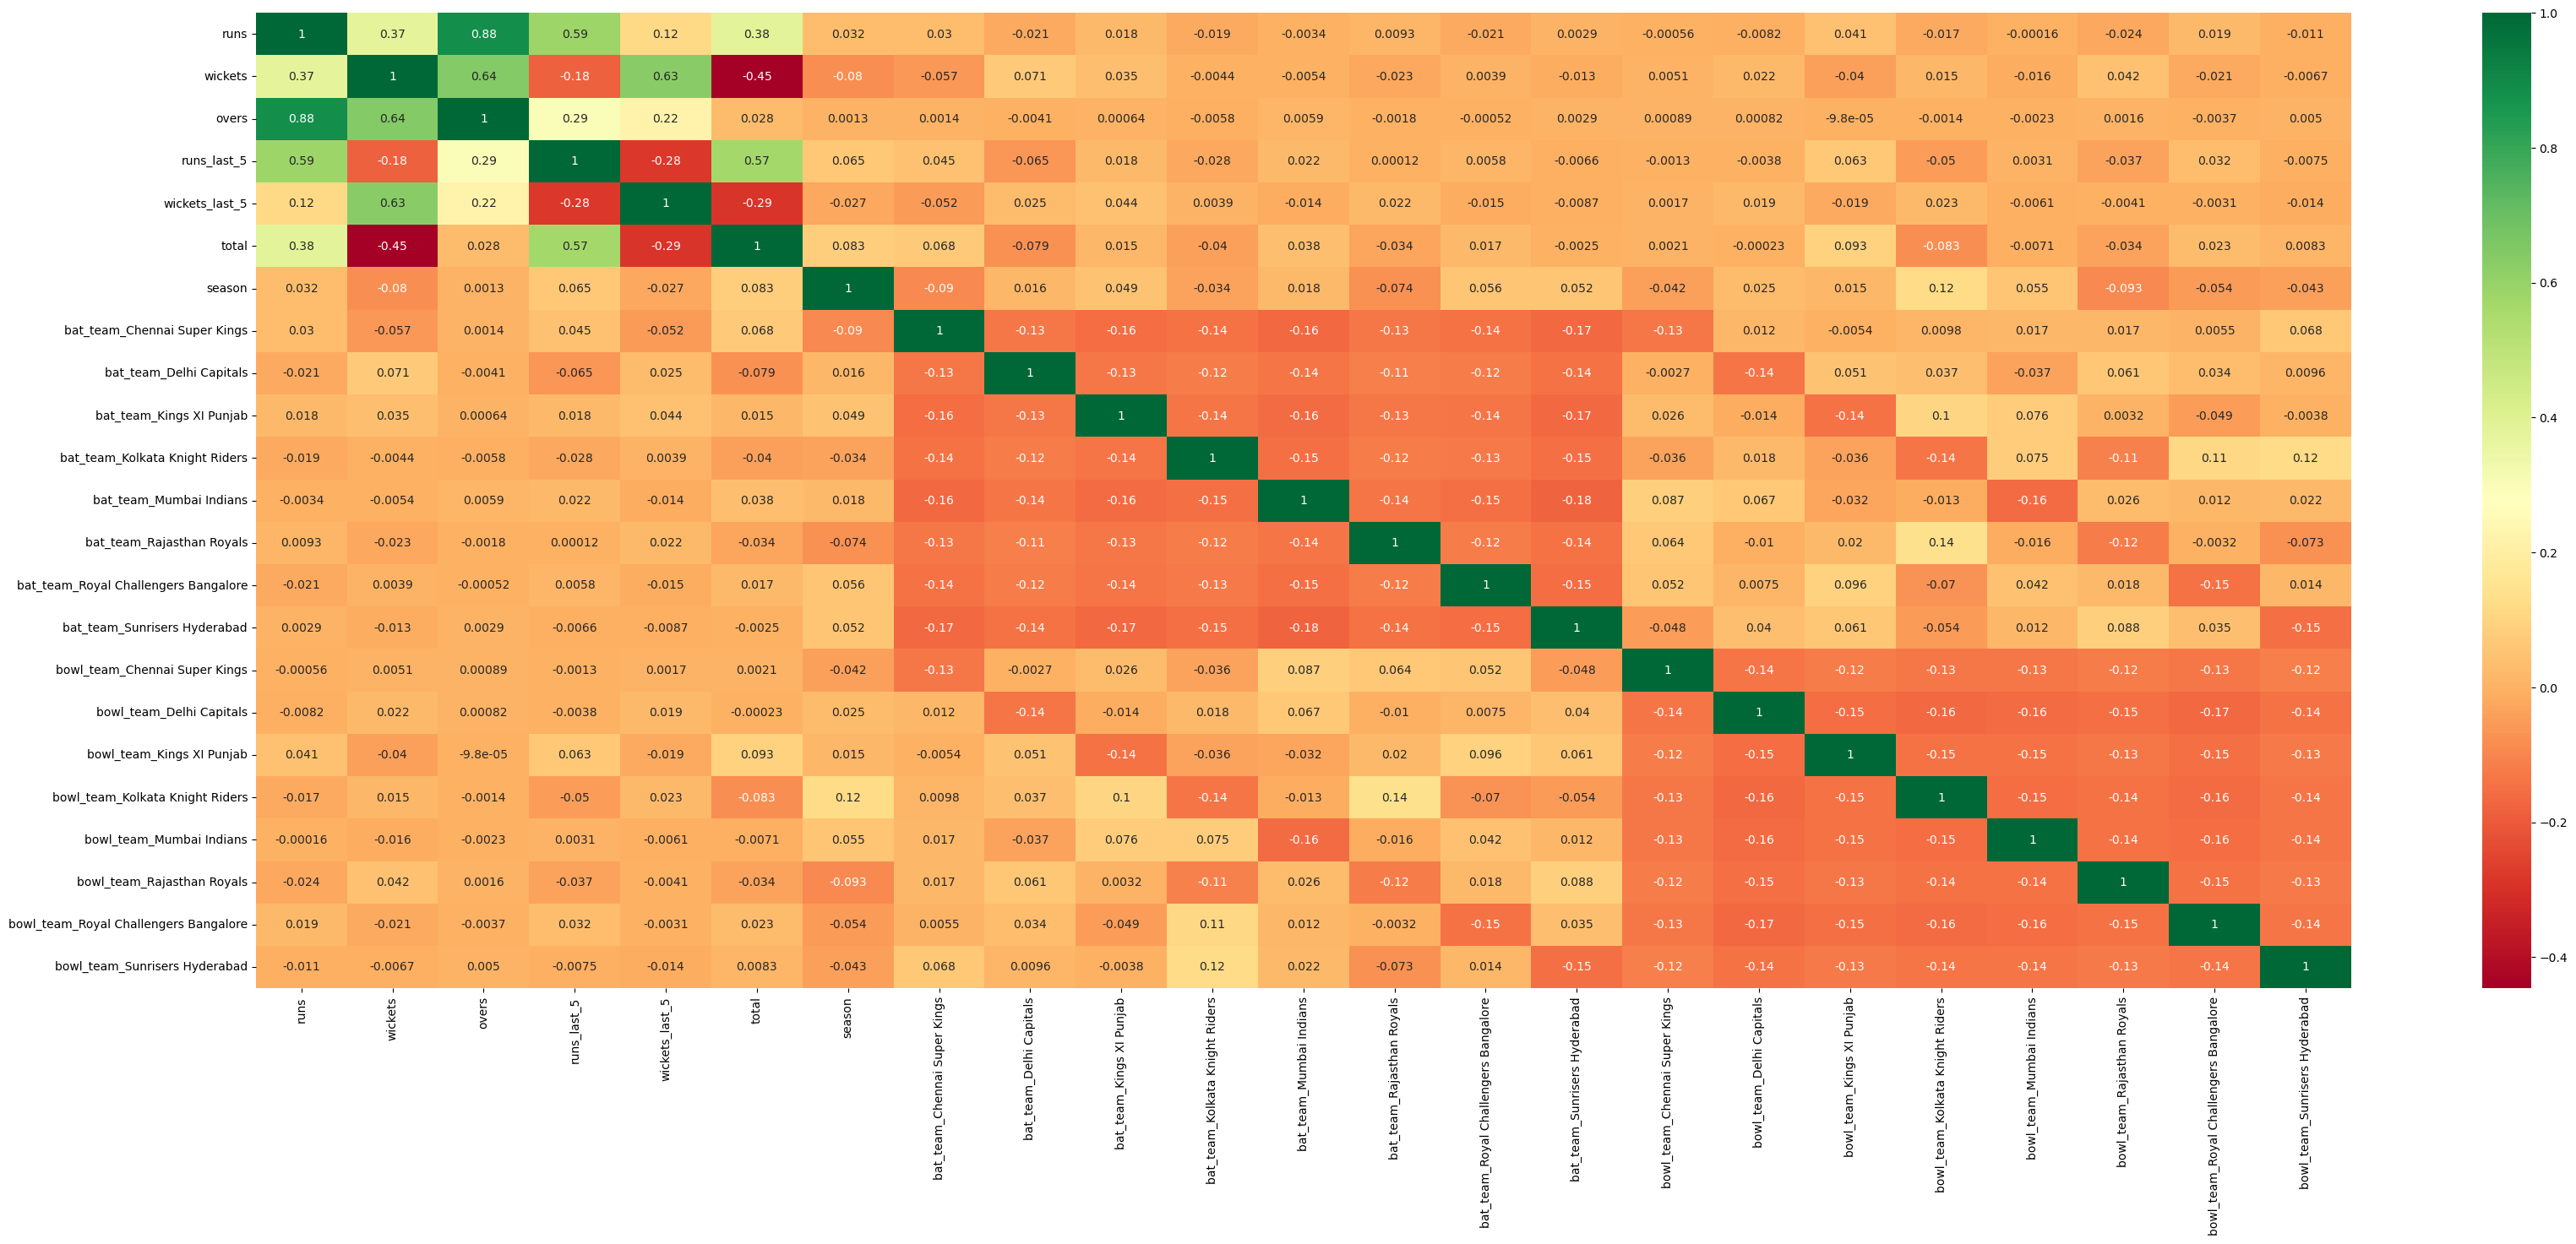

In [522]:
cor=df.corr()   
plt.figure(figsize=(40,15))
sns.heatmap(cor,annot=True,cmap="RdYlGn")

### Showing important data in table

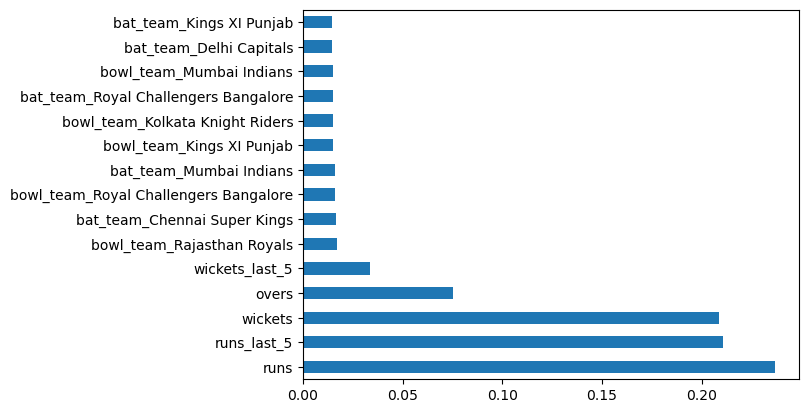

In [111]:
from sklearn.ensemble import ExtraTreesRegressor
model=ExtraTreesRegressor()
model.fit(x_train,y_train)


feat_import=pd.Series(model.feature_importances_,index=x_train.columns)
feat_import.nlargest(15).plot(kind="barh")
plt.show()

In [113]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error #score and error in model

In [484]:
r2_scores={}
mae={}

# Linear Regression model Binding and Evaluation

prediction:
 [153.75042855 173.51751192 168.09471611 ... 191.91620135 149.26679697
 181.62032398]


r2_score on training data : 0.6517279138780163 
r2_score on test data : 0.6401199672362543 
mae : 13.059713530665043
mse : 301.09830827059875
rmse : 17.352184538858463
score 0.6401199672362543


<Axes: xlabel='total', ylabel='Density'>

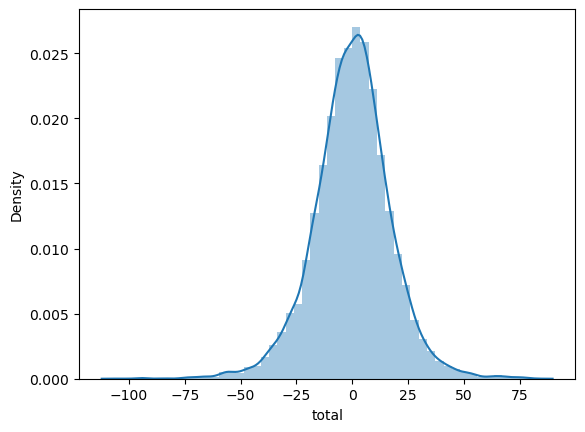

In [485]:
#linear Regession
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

prediction=lr.predict(x_test)
print("prediction:\n",prediction)
print("\n")

print("r2_score on training data : {} ".format(r2_score(y_train,lr.predict(x_train))))
print("r2_score on test data : {} ".format(r2_score(y_test,prediction)))
print("mae : {}".format(mean_absolute_error(y_test,prediction)))
print("mse : {}".format(mean_squared_error(y_test,prediction)))
print("rmse : {}".format(np.sqrt(mean_squared_error(y_test,prediction))))

r2_scores["Linear_Regression"] = r2_score(y_test,prediction)
mae["Linear_Regression"] = mean_absolute_error(y_test,prediction)

s=lr.score(x_test,y_test)
print("score",s)

sns.distplot(y_test-prediction)

# DecisionTreeRegressor model Binding and Evaluation

prediction:
 [161.03326333 161.03326333 161.03326333 ... 161.03326333 161.03326333
 161.03326333]


r2_score on training data : 0.12313213286051528 
r2_score on test data : 0.11462081581663663 
mae : 21.326352039335493
mse : 740.7640054057186
rmse : 27.216980093421803
score 0.11462081581663663


<Axes: xlabel='total', ylabel='Density'>

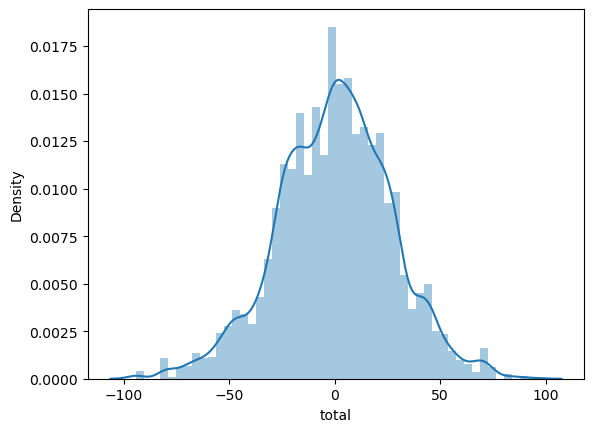

In [486]:
# decision Tree
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(max_depth=5,max_features=3,random_state=42)
dt.fit(x_train,y_train)

prediction=dt.predict(x_test)
print("prediction:\n",prediction)
print("\n")

print("r2_score on training data : {} ".format(r2_score(y_train,dt.predict(x_train))))
print("r2_score on test data : {} ".format(r2_score(y_test,prediction)))
print("mae : {}".format(mean_absolute_error(y_test,prediction)))
print("mse : {}".format(mean_squared_error(y_test,prediction)))
print("rmse : {}".format(np.sqrt(mean_squared_error(y_test,prediction))))

r2_scores["Decision_Tree"] = r2_score(y_test,prediction)
mae["Decision_Tree"] = mean_absolute_error(y_test,prediction)

s=dt.score(x_test,y_test)
print("score",s)

sns.distplot(y_test-prediction)

# RandomForestRegressor model Binding and Evaluation

prediction:
 [167.81 166.22 182.91 ... 179.77 162.27 171.13]


r2_score on training data : 0.9885650522708437 
r2_score on test data : 0.919541325862224 
mae : 4.796547608247329
mse : 67.31679577367271
rmse : 8.20468133285338
score 0.919541325862224


<Axes: xlabel='total', ylabel='Density'>

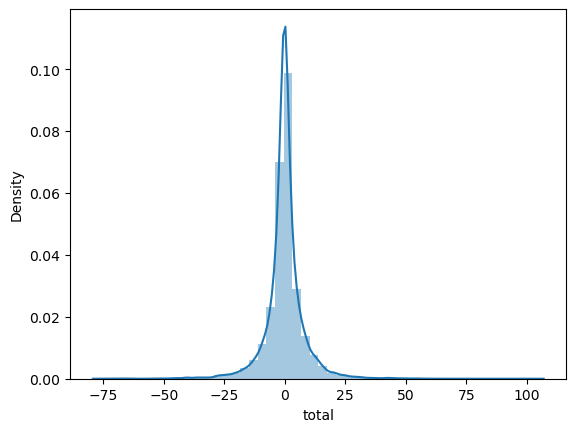

In [487]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)


prediction=rf.predict(x_test)
print("prediction:\n",prediction)
print("\n")

print("r2_score on training data : {} ".format(r2_score(y_train,rf.predict(x_train))))
print("r2_score on test data : {} ".format(r2_score(y_test,prediction)))
print("mae : {}".format(mean_absolute_error(y_test,prediction)))
print("mse : {}".format(mean_squared_error(y_test,prediction)))
print("rmse : {}".format(np.sqrt(mean_squared_error(y_test,prediction))))

r2_scores["Random_Forest"] = r2_score(y_test,prediction)
mae["Random_Forest"] = mean_absolute_error(y_test,prediction)

s=rf.score(x_test,y_test)
print("score",s)

sns.distplot(y_test-prediction)

# ExtraTreesRegressor model Binding and Evaluation

prediction:
 [168.07 165.16 189.16 ... 187.18 163.6  169.35]


r2_score on training data : 0.9990423441159021 
r2_score on test data : 0.946948491329158 
mae : 2.933312383612663
mse : 44.38623446074862
rmse : 6.66229948747042
score 0.946948491329158


<Axes: xlabel='total', ylabel='Density'>

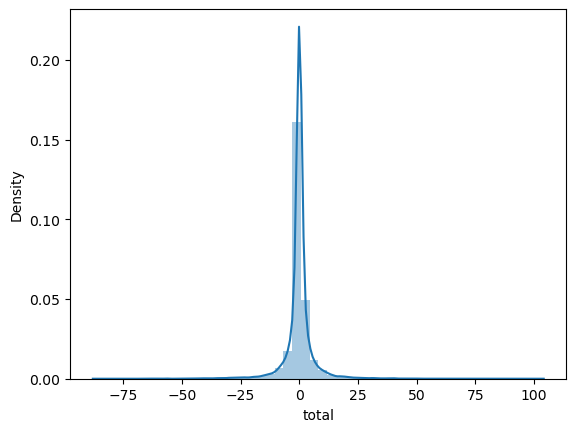

In [488]:
from sklearn.ensemble import ExtraTreesRegressor
ext=ExtraTreesRegressor()
ext.fit(x_train,y_train)

prediction=ext.predict(x_test)
print("prediction:\n",prediction)
print("\n")

print("r2_score on training data : {} ".format(r2_score(y_train,ext.predict(x_train))))
print("r2_score on test data : {} ".format(r2_score(y_test,prediction)))
print("mae : {}".format(mean_absolute_error(y_test,prediction)))
print("mse : {}".format(mean_squared_error(y_test,prediction)))
print("rmse : {}".format(np.sqrt(mean_squared_error(y_test,prediction))))

r2_scores[" Extra_Trees"] = r2_score(y_test,prediction)
mae[" Extra_Trees"] = mean_absolute_error(y_test,prediction)

s=ext.score(x_test,y_test)
print("score",s)

sns.distplot(y_test-prediction)

#  GradientBoostingRegressor model Binding and Evaluation

prediction:
 [152.35700987 165.43256368 165.64566594 ... 190.17164178 153.58963694
 180.04921297]


r2_score on training data : 0.6809170338994593 
r2_score on test data : 0.6655580932841276 
mae : 12.422208207485404
mse : 279.8151693874333
rmse : 16.7276767480554
score 0.6655580932841276


<Axes: xlabel='total', ylabel='Density'>

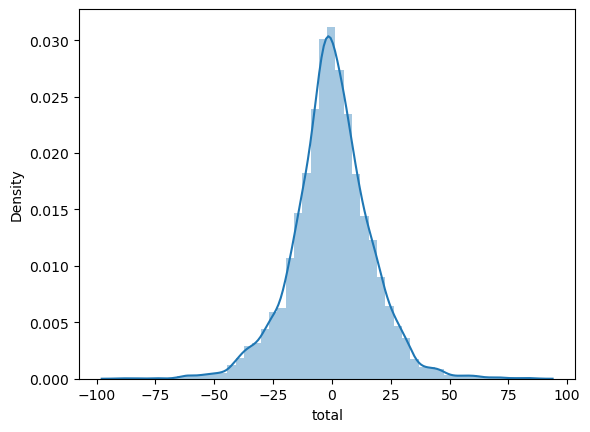

In [489]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
gbr.fit(x_train,y_train)

prediction=gbr.predict(x_test)
print("prediction:\n",prediction)
print("\n")

print("r2_score on training data : {} ".format(r2_score(y_train,gbr.predict(x_train))))
print("r2_score on test data : {} ".format(r2_score(y_test,prediction)))
print("mae : {}".format(mean_absolute_error(y_test,prediction)))
print("mse : {}".format(mean_squared_error(y_test,prediction)))
print("rmse : {}".format(np.sqrt(mean_squared_error(y_test,prediction))))

r2_scores["Gradient_Boosting"] = r2_score(y_test,prediction)
mae["Gradient_Boosting"] = mean_absolute_error(y_test,prediction)

s=gbr.score(x_test,y_test)
print("score",s)

sns.distplot(y_test-prediction)

#  XGBRegressor model Binding and Evaluation

prediction:
 [165.97865 165.216   170.65129 ... 187.75851 158.26854 171.9589 ]


r2_score on training data : 0.8727421805682452 
r2_score on test data : 0.827239800685732 
mae : 8.720890776849103
mse : 144.54206683971884
rmse : 12.022564902703534
score 0.827239800685732


<Axes: xlabel='total', ylabel='Density'>

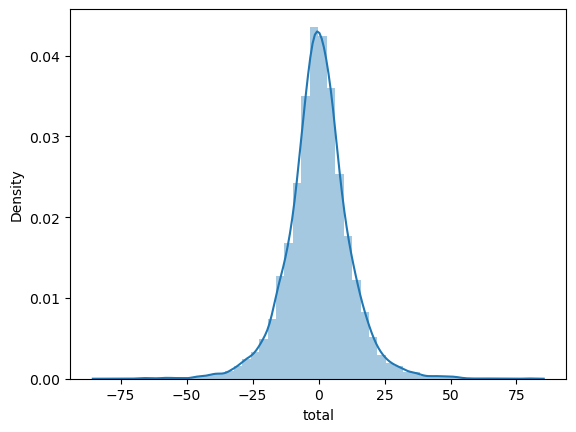

In [490]:
from xgboost import XGBRegressor
xg=XGBRegressor()
xg.fit(x_train,y_train)

prediction=xg.predict(x_test)
print("prediction:\n",prediction)
print("\n")

print("r2_score on training data : {} ".format(r2_score(y_train,xg.predict(x_train))))
print("r2_score on test data : {} ".format(r2_score(y_test,prediction)))
print("mae : {}".format(mean_absolute_error(y_test,prediction)))
print("mse : {}".format(mean_squared_error(y_test,prediction)))
print("rmse : {}".format(np.sqrt(mean_squared_error(y_test,prediction))))

r2_scores["XGB"] = r2_score(y_test,prediction)
mae["XGB"] = mean_absolute_error(y_test,prediction)

s=xg.score(x_test,y_test)
print("score",s)

sns.distplot(y_test-prediction)

# Plotting all Model r2_Score

[Text(0, 0, '0.946948'),
 Text(0, 0, '0.919541'),
 Text(0, 0, '0.82724'),
 Text(0, 0, '0.665558'),
 Text(0, 0, '0.64012'),
 Text(0, 0, '0.114621')]

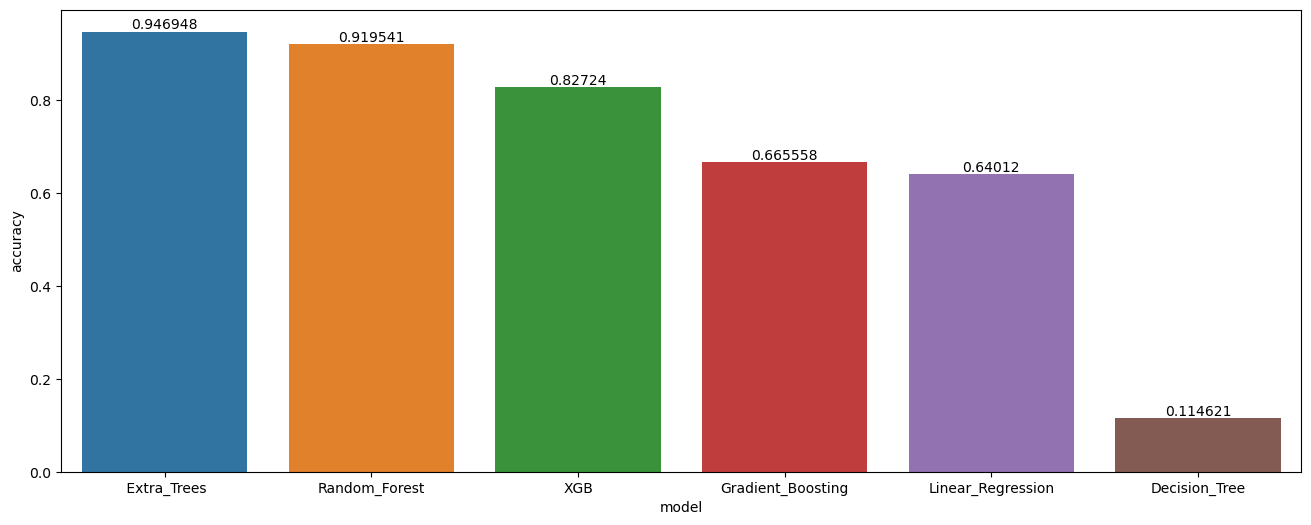

In [491]:
plt.figure(figsize=(16,6))
score=pd.DataFrame(r2_scores.items(),columns=["model","accuracy"])
ax=sns.barplot(score.sort_values(by="accuracy",ascending=False),x="model",y="accuracy")
ax.bar_label(ax.containers[0])

# Plotting all Model Mean_absolutr_error 

[Text(0, 0, '2.93331'),
 Text(0, 0, '4.79655'),
 Text(0, 0, '8.72089'),
 Text(0, 0, '12.4222'),
 Text(0, 0, '13.0597'),
 Text(0, 0, '21.3264')]

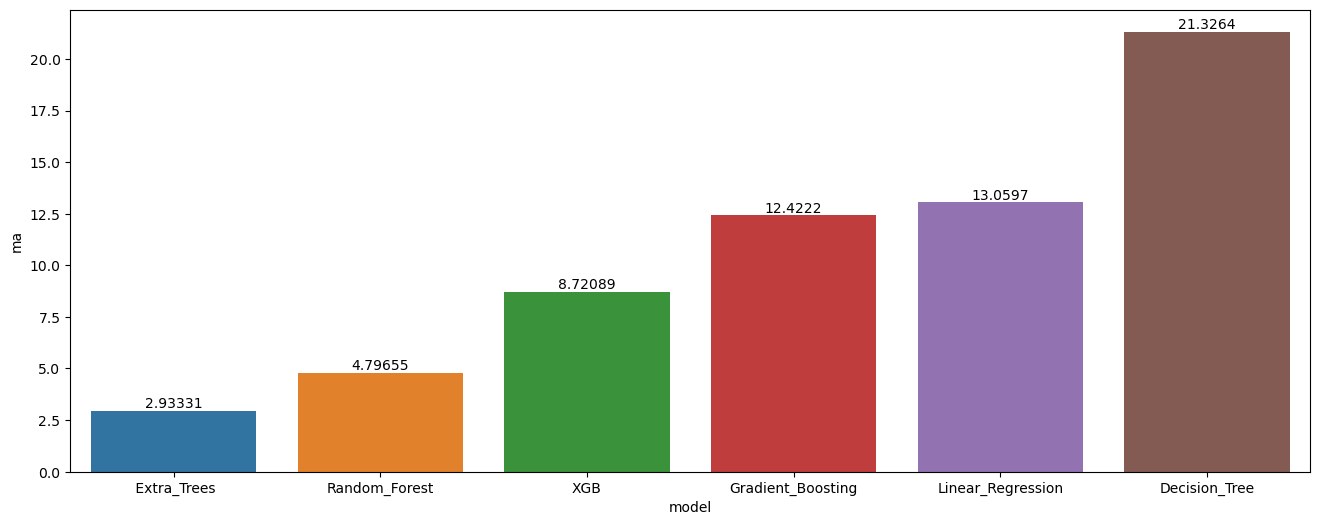

In [492]:
plt.figure(figsize=(16,6))
score=pd.DataFrame(mae.items(),columns=["model","ma"])
ax=sns.barplot(score.sort_values(by="ma",ascending=True),x="model",y="ma")
ax.bar_label(ax.containers[0])

In [493]:
x_test

,runs,wickets,overs,runs_last_5,wickets_last_5,bat_team_Chennai Super Kings,bat_team_Delhi Capitals,bat_team_Kings XI Punjab,bat_team_Kolkata Knight Riders,bat_team_Mumbai Indians,...,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Chennai Super Kings,bowl_team_Delhi Capitals,bowl_team_Kings XI Punjab,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Rajasthan Royals,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad
7967,164,8,19,27,5,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
23245,158,4,19,31,2,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
33993,40,0,5,33,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
37117,80,5,11,26,3,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
51726,119,4,12,35,2,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5436,74,1,8,54,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
6835,117,3,14,41,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5473,134,2,14,50,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
48674,76,3,11,39,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


# Our Own input to model 

In [501]:
# new prediction
data=[59,3,10.5,30,2,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0]
score=ext.predict([data])
print("prediction: ",score)
print(f"final score will be in {score-5} and {score+5}")

prediction:  [148.9]
final score will be in [143.9] and [153.9]


In [495]:
# new prediction
data=[120,0,10,60,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0]
score=ext.predict([data])
print("prediction: ",score)
print(f"final score will be in {score-5} and {score+5}")

prediction:  [188.21]
final score will be in [183.21] and [193.21]


In [506]:
import pickle
exfile_name="predict ipl_1stinnings_score_ext.pkl"
pickle.dump(ext,open(exfile_name,"wb"))

In [507]:
loaded_model=pickle.load(open("predict ipl_1stinnings_score_ext.pkl","rb"))

In [508]:
pred=loaded_model.predict(x_test)

In [509]:
pred

array([168.07, 165.16, 189.16, ..., 187.18, 163.6 , 169.35])

In [510]:
print(r2_score(y_test,pred))
print(mean_squared_error(y_test,pred))

0.946948491329158
44.38623446074862


In [513]:
dcfile_name="prediction_ipl1stinn_dc.pkl"
pickle.dump(dt,open(dcfile_name,"wb"))

In [514]:
load_model=pickle.load(open("prediction_ipl1stinn_dc.pkl","rb"))

In [515]:
pre=load_model.predict(x_test)

In [516]:
pre

array([161.03326333, 161.03326333, 161.03326333, ..., 161.03326333,
       161.03326333, 161.03326333])

In [520]:
print(r2_score(y_test,pre))
print(mean_absolute_error(y_test,pre))

0.11462081581663663
21.326352039335493
